# GBDT для задачи Traffic & Mobility на геоданных Санкт-Петербурга

## Цель работы

Оценить потенциальную транспортную нагрузку на сегменты уличной сети Санкт-Петербурга на основе геоданных OpenStreetMap с использованием GBDT.

## 0. Установка и импорт библиотек

In [ ]:
!pip install osmnx geopandas shapely scikit-learn matplotlib contextily mapclassify

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import box
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.neighbors import BallTree

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.2 MB/s eta 0:00:00


## 1. Область исследования

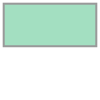

In [ ]:
# Центральная часть Санкт-Петербурга
bbox = (30.18, 59.86, 30.55, 60.03)
polygon_wgs = box(*bbox)

polygon_wgs

## 2. Загрузка уличной сети

In [ ]:
# Загрузка графа дорог
G = ox.graph_from_polygon(
    polygon_wgs,          # polygon_wgs
    network_type="drive", # "drive"
    simplify=True,
    retain_all=False
)

# Получение GeoDataFrame узлов и рёбер
nodes, edges = ox.graph_to_gdfs(G)

print(edges.shape)
edges.head()

(16176, 15)


osmid       highway lanes  maxspeed  \
u      v          key                                                          
219808 2327840    0                   33997807  primary_link     2  RU:urban   
       389449562  0                  201380605       primary     3  RU:urban   
219811 1832085962 0                   33997784  primary_link     2  RU:urban   
       1465050831 0    [1123339577, 178581714]       primary     3  RU:urban   
219812 249890545  0                    4459876       primary     2  RU:urban   

                       oneway reversed      length                       name  \
u      v          key                                                           
219808 2327840    0     False    False   26.026139                        NaN   
       389449562  0      True    False   31.504625         Лиговский проспект   
219811 1832085962 0     False    False   27.905147                        NaN   
       1465050831 0      True    False  394.654005         Лиговский проспект   
219812 249890545  0      True    False   33.758153  Воздухоплавательная улица   

                                                                geometry  \
u      v          key                                                      
219808 2327840    0    LINESTRING (30.33142 59.89509, 30.33109 59.89526)   
       389449562  0    LINESTRING (30.33142 59.89509, 30.33182 59.89529)   
219811 1832085962 0      LINESTRING (30.33748 59.8993, 30.33793 59.8992)   
       1465050831 0    LINESTRING (30.33748 59.8993, 30.3372 59.89897...   
219812 249890545  0    LINESTRING (30.33955 59.90173, 30.33982 59.90146)   

                      bridge junction  ref width tunnel access  
u      v          key                                           
219808 2327840    0      NaN      NaN  NaN   NaN    NaN    NaN  
       389449562  0      NaN      NaN  NaN   NaN    NaN    NaN  
219811 1832085962 0      NaN      NaN  NaN   NaN    NaN    NaN  
       1465050831 0      NaN      NaN  NaN   NaN    NaN    NaN  
219812 249890545  0      NaN      NaN  NaN   NaN    NaN    NaN

## 3. Приведение к метрической CRS

In [ ]:
# Перевод в метрическую CRS (UTM зона 36N)
edges_m = edges.to_crs("EPSG:32636")

edges_m.crs

<Projected CRS: EPSG:32636>
Name: WGS 84 / UTM zone 36N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 30°E and 36°E, northern hemisphere between equator and 84°N, onshore and offshore. Belarus. Cyprus. Egypt. Ethiopia. Finland. Israel. Jordan. Kenya. Lebanon. Moldova. Norway. Russian Federation. Saudi Arabia. Sudan. Syria. Türkiye (Turkey). Uganda. Ukraine.
- bounds: (30.0, 0.0, 36.0, 84.0)
Coordinate Operation:
- name: UTM zone 36N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

## 4. Геометрические признаки

In [ ]:
roads = edges_m.copy()

# Длина сегмента в метрах
roads["length_m_geom"] = roads.geometry.length

# Центроид сегмента
roads["centroid_x"] = roads.geometry.centroid.x
roads["centroid_y"] = roads.geometry.centroid.y

# Прямое расстояние между началом и концом
def straight_distance(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

roads["straight_dist_m"] = roads.geometry.apply(straight_distance)

# Извилистость
roads["sinuosity"] = roads["length_m_geom"] / roads["straight_dist_m"].replace(0, np.nan)
roads["sinuosity"] = roads["sinuosity"].replace([np.inf, -np.inf], np.nan).fillna(1)

# Направление дороги
def segment_angle(geom):
    coords = list(geom.coords)
    x1, y1 = coords[0]
    x2, y2 = coords[-1]
    dx = x2 - x1
    dy = y2 - y1
    return np.arctan2(dy, dx)

roads["angle_rad"] = roads.geometry.apply(segment_angle)

roads[["length_m_geom", "straight_dist_m", "sinuosity", "angle_rad"]].describe()

,length_m_geom,straight_dist_m,sinuosity,angle_rad
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,183.554633,177.120246,1.045379,0.001167
std,243.995907,228.388397,0.896788,1.818570
min,1.236514,0.000000,1.000000,-3.141433
25%,28.296945,27.432919,1.000000,-1.582503
50%,106.825070,104.682539,1.000018,-0.000176
75%,248.837794,243.176946,1.002707,1.554398
max,6640.370574,5357.940848,76.797540,3.140873


## 5. One-hot encoding типа дороги

In [ ]:
# Приведение highway к строке
roads["highway_str"] = roads["highway"].apply(lambda x: ",".join(x) if isinstance(x, list) else str(x))

# One-hot encoding
highway_dummies = pd.get_dummies(roads["highway_str"], prefix="highway")

# Добавление к основному DataFrame
roads = pd.concat([roads, highway_dummies], axis=1)

highway_dummies.head()

highway_living_street  highway_motorway  \
u      v          key                                            
219808 2327840    0                    False             False   
       389449562  0                    False             False   
219811 1832085962 0                    False             False   
       1465050831 0                    False             False   
219812 249890545  0                    False             False   

                       highway_primary  highway_primary_link  \
u      v          key                                          
219808 2327840    0              False                  True   
       389449562  0               True                 False   
219811 1832085962 0              False                  True   
       1465050831 0               True                 False   
219812 249890545  0               True                 False   

                       highway_primary_link,primary  \
u      v          key                                 
219808 2327840    0                           False   
       389449562  0                           False   
219811 1832085962 0                           False   
       1465050831 0                           False   
219812 249890545  0                           False   

                       highway_primary_link,residential  highway_residential  \
u      v          key                                                          
219808 2327840    0                               False                False   
       389449562  0                               False                False   
219811 1832085962 0                               False                False   
       1465050831 0                               False                False   
219812 249890545  0                               False                False   

                       highway_residential,living_street  \
u      v          key                                      
219808 2327840    0                                False   
       389449562  0                                False   
219811 1832085962 0                                False   
       1465050831 0                                False   
219812 249890545  0                                False   

                       highway_residential,unclassified  highway_secondary  \
u      v          key                                                        
219808 2327840    0                               False              False   
       389449562  0                               False              False   
219811 1832085962 0                               False              False   
       1465050831 0                               False              False   
219812 249890545  0                               False              False   

                       ...  highway_secondary_link,secondary  \
u      v          key  ...                                     
219808 2327840    0    ...                             False   
       389449562  0    ...                             False   
219811 1832085962 0    ...                             False   
       1465050831 0    ...                             False   
219812 249890545  0    ...                             False   

                       highway_tertiary  highway_tertiary,residential  \
u      v          key                                                   
219808 2327840    0               False                         False   
       389449562  0               False                         False   
219811 1832085962 0               False                         False   
       1465050831 0               False                         False   
219812 249890545  0               False                         False   

                       highway_tertiary,unclassified  highway_tertiary_link  \
u      v          key                                                         
219808 2327840    0                            False                  False  

## 6. Загрузка POI и остановок

In [ ]:
# Теги для POI
poi_tags = {
    "amenity": True,
    "shop": True,
    "office": True,
    "tourism": True,
    "leisure": True,
}

# Теги для остановок
stop_tags = {
    "highway": "bus_stop",
    "public_transport": True,
    "railway": ["station", "subway_entrance", "tram_stop"]
}

# Загрузка данных
pois = ox.features_from_polygon(polygon_wgs, tags=poi_tags)
stops = ox.features_from_polygon(polygon_wgs, tags=stop_tags)

print("POI:", pois.shape)
print("Stops:", stops.shape)

POI: (96942, 1227)
Stops: (7435, 124)


## 7. Подготовка точечных данных

In [ ]:
def to_points(gdf, crs_target):
    gdf = gdf.copy()
    gdf = gdf.to_crs(crs_target)
    gdf["geometry"] = gdf.geometry.representative_point()
    return gdf

pois_m = to_points(pois, roads.crs)
stops_m = to_points(stops, roads.crs)

pois_m = pois_m[~pois_m.geometry.is_empty & pois_m.geometry.notna()]
stops_m = stops_m[~stops_m.geometry.is_empty & stops_m.geometry.notna()]

pois_m.head()

geometry         amenity  \
element id                                                          
node    29001764   POINT (346911.245 6645602.235)  ferry_terminal   
        248465159  POINT (355699.365 6655570.419)             NaN   
        248465166  POINT (355735.863 6655631.331)             NaN   
        248701411   POINT (354243.62 6655104.647)             NaN   
        249082841  POINT (349260.755 6647401.446)             NaN   

                          railway        contact:email  \
element id                                               
node    29001764   ferry_terminal                  NaN   
        248465159             NaN  fclub-spb@yandex.ru   
        248465166             NaN                  NaN   
        248701411             NaN                  NaN   
        249082841             NaN                  NaN   

                                   contact:phone       contact:website  \
element id                                                               
node    29001764                             NaN                   NaN   
        248465159  +7 812 2918980;+7 812 5908868  https://fclub-spb.ru   
        248465166                            NaN                   NaN   
        248701411                            NaN                   NaN   
        249082841                            NaN                   NaN   

                         leisure            name  \
element id                                         
node    29001764             NaN             NaN   
        248465159  sports_centre          Фитнес   
        248465166            NaN    Всё для дома   
        248701411            NaN             NaN   
        249082841            NaN  Петру Великому   

                                          opening_hours        shop  ...  \
element id                                                           ...   
node    29001764                                    NaN         NaN  ...   
        248465159  Mo-Fr 07:00-23:00; Sa-Su 09:00-22:00         NaN  ...   
        248465166                                   NaN         yes  ...   
        248701411                                   NaN  car_repair  ...   
        249082841                                   NaN         NaN  ...   

                  brand:wikipedia:ar brand:short canoe:type  \
element id                                                    
node    29001764                 NaN         NaN        NaN   
        248465159                NaN         NaN        NaN   
        248465166                NaN         NaN        NaN   
        248701411                NaN         NaN        NaN   
        249082841                NaN         NaN        NaN   

                  education_programme:FR ref:en ref:ru addr:housenumber2  \
element id                                                                 
node    29001764                     NaN    NaN    NaN               NaN   
        248465159                    NaN    NaN    NaN               NaN   
        248465166                    NaN    NaN    NaN               NaN   
        248701411                    NaN    NaN    NaN               NaN   
        249082841                    NaN    NaN    NaN               NaN   

                  blood:plasma blood:whole donation:compensation  
element id                                                        
node    29001764           NaN         NaN                   NaN  
        248465159          NaN         NaN                   NaN  
        248465166          NaN         NaN                   NaN  
        248701411          NaN         NaN                   NaN  
        249082841          NaN         NaN                   NaN  

[5 rows x 1227 columns]

## 8. Пространственные признаки через BallTree

In [ ]:
def nearest_and_count(source_gdf, target_gdf, radius=300):
    source_coords = np.vstack([
        source_gdf.geometry.centroid.x,
        source_gdf.geometry.centroid.y
    ]).T

    target_coords = np.vstack([
        target_gdf.geometry.x,
        target_gdf.geometry.y
    ]).T

    tree = BallTree(target_coords, metric="euclidean")

    dist, _ = tree.query(source_coords, k=1)
    nearest_dist = dist[:, 0]

    counts = tree.query_radius(source_coords, r=radius, count_only=True)

    return nearest_dist, counts

# Используем центроиды дорог как точки для расчёта
road_points = roads.copy()
road_points["geometry"] = road_points.geometry.centroid

# Расчёт расстояний и количества объектов
roads["dist_to_poi_m"], roads["poi_count_300m"] = nearest_and_count(road_points, pois_m, radius=300)
roads["dist_to_stop_m"], roads["stop_count_300m"] = nearest_and_count(road_points, stops_m, radius=300)

roads[["dist_to_poi_m", "poi_count_300m", "dist_to_stop_m", "stop_count_300m"]].describe()

,dist_to_poi_m,poi_count_300m,dist_to_stop_m,stop_count_300m
count,16176.000000,16176.000000,16176.000000,16176.000000
mean,49.583569,140.513229,143.417061,9.910423
std,57.391652,133.199795,145.281730,7.527159
min,0.293001,0.000000,0.160834,0.000000
25%,20.350445,47.000000,48.666572,4.000000
50%,34.839845,96.000000,103.713260,8.000000
75%,58.375453,197.000000,191.644245,14.000000
max,1095.915800,1003.000000,1695.642643,56.000000


## 9. Графовые признаки

In [ ]:
# Сброс индекса для доступа к u, v
roads = roads.reset_index()

# Словарь степеней узлов графа
node_degree = dict(G.degree())

# Добавление степеней начального и конечного узлов
roads["u_degree"] = roads["u"].map(node_degree)
roads["v_degree"] = roads["v"].map(node_degree)
roads["mean_node_degree"] = (roads["u_degree"] + roads["v_degree"]) / 2

roads[["u_degree", "v_degree", "mean_node_degree"]].describe()

,u_degree,v_degree,mean_node_degree
count,16176.000000,16176.000000,16176.000000
mean,4.424641,4.423405,4.424023
std,1.320487,1.322241,1.082633
min,1.000000,1.000000,1.500000
25%,3.000000,3.000000,3.500000
50%,4.000000,4.000000,4.000000
75%,6.000000,6.000000,5.000000
max,10.000000,10.000000,8.500000


## 10. Формирование целевой переменной

In [ ]:
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# Нормировка признаков
roads["length_norm"] = minmax(roads["length_m_geom"].clip(upper=roads["length_m_geom"].quantile(0.99)))
roads["poi_count_norm"] = minmax(roads["poi_count_300m"])
roads["stop_count_norm"] = minmax(roads["stop_count_300m"])
roads["degree_norm"] = minmax(roads["mean_node_degree"])
roads["near_poi_norm"] = 1 - minmax(roads["dist_to_poi_m"].clip(upper=roads["dist_to_poi_m"].quantile(0.99)))
roads["near_stop_norm"] = 1 - minmax(roads["dist_to_stop_m"].clip(upper=roads["dist_to_stop_m"].quantile(0.99)))

# Случайный шум для реалистичности
rng = np.random.default_rng(42)
noise = rng.normal(0, 0.05, size=len(roads))

# Формула целевой переменной
roads["traffic_load_score"] = (
    0.30 * roads["length_norm"] +
    0.25 * roads["poi_count_norm"] +
    0.15 * roads["stop_count_norm"] +
    0.15 * roads["degree_norm"] +
    0.10 * roads["near_poi_norm"] +
    0.05 * roads["near_stop_norm"] +
    noise
)

roads["traffic_load_score"] = roads["traffic_load_score"].clip(0, 1)
roads["traffic_load_score"].describe()

,traffic_load_score
count,16176.000000
mean,0.302632
std,0.092974
min,0.000000
25%,0.238065
50%,0.297243
75%,0.363774
max,0.771029


## 11. Подготовка признаков для модели

In [ ]:
# Числовые признаки
base_features = [
    "length_m_geom",
    "straight_dist_m",
    "sinuosity",
    "angle_rad",
    "centroid_x",
    "centroid_y",
    "dist_to_poi_m",
    "poi_count_300m",
    "dist_to_stop_m",
    "stop_count_300m",
    "mean_node_degree",
]

# Категориальные признаки (one-hot)
highway_features = list(highway_dummies.columns)

# Объединение
feature_cols = base_features + highway_features

# Матрица признаков и целевая переменная
X = roads[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
y = roads["traffic_load_score"]

X.shape, y.shape

((16176, 32), (16176,))

## 12. Разделение на train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

X_train.shape, X_test.shape

((12132, 32), (4044, 32))

## 13. Обучение GBDT-модели

In [ ]:
model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)

model.fit(X_train, y_train)

HistGradientBoostingRegressor(learning_rate=0.05, max_iter=200, random_state=42)

## 14. Оценка качества

In [ ]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(f"Train MAE: {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Train R2: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R2: {r2_score(y_test, y_pred_test):.4f}")

Train MAE: 0.0373
Test MAE: 0.0399
Train RMSE: 0.0469
Test RMSE: 0.0502
Train R2: 0.7454
Test R2: 0.7097


## 15. Настройка гиперпараметров

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_leaf_nodes': [31, 63, 127]
}

grid_search = GridSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best CV MAE: {-grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# Оценка лучшей модели
y_pred_best = best_model.predict(X_test)
print(f"Test MAE (tuned): {mean_absolute_error(y_test, y_pred_best):.4f}")
print(f"Test R2 (tuned): {r2_score(y_test, y_pred_best):.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31}
Best CV MAE: 0.0413
Test MAE (tuned): 0.0399
Test R2 (tuned): 0.7100


## 16. Прогноз для всех сегментов (с tuned-моделью)

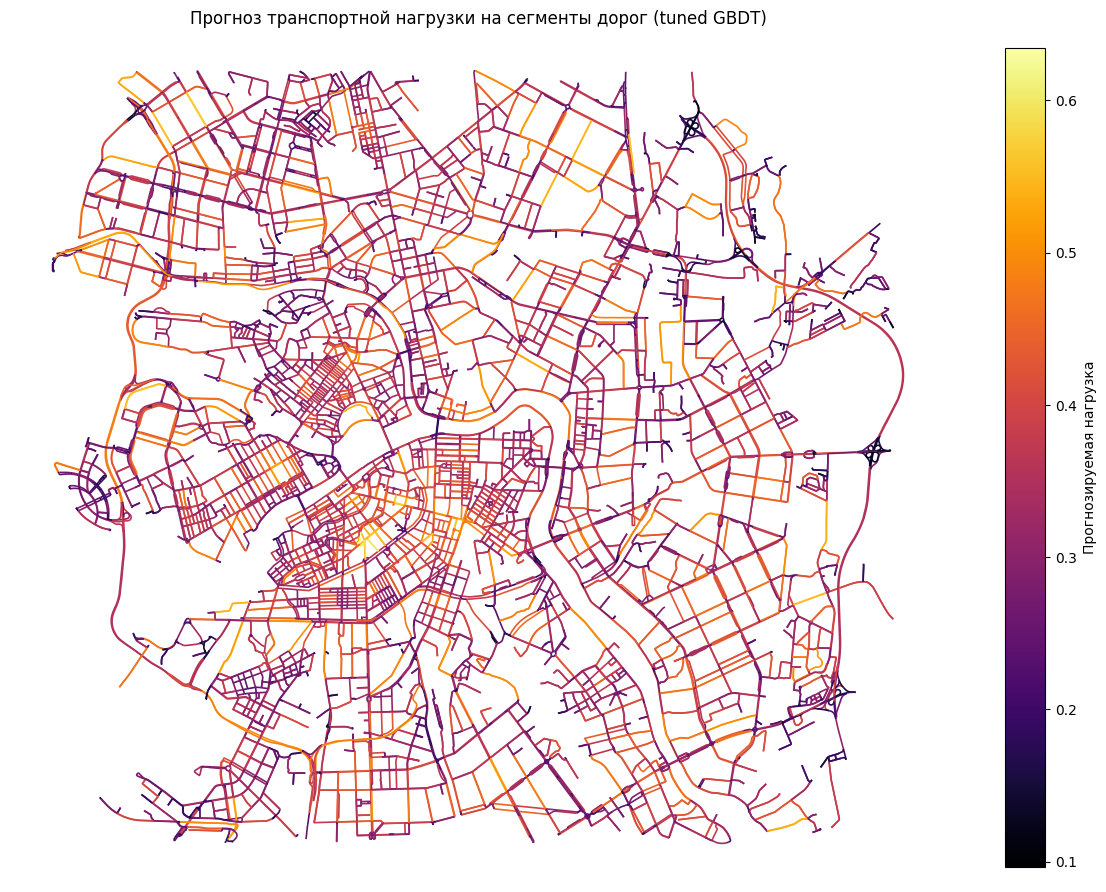

In [ ]:
# Прогноз для всех сегментов с использованием лучшей модели
roads["predicted_traffic_load"] = best_model.predict(X)

# Возвращаем геометрию в WGS84 для визуализации
roads_wgs = gpd.GeoDataFrame(roads, geometry="geometry", crs=edges_m.crs).to_crs(4326)

fig, ax = plt.subplots(figsize=(12, 12))
roads_wgs.plot(
    ax=ax,
    column="predicted_traffic_load",
    linewidth=1.2,
    legend=True,
    cmap="inferno",
    legend_kwds={"label": "Прогнозируемая нагрузка", "shrink": 0.7}
)
ax.set_title("Прогноз транспортной нагрузки на сегменты дорог (tuned GBDT)")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 17. Анализ важности признаков

In [ ]:
# Permutation importance для лучшей модели
perm_importance = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

# Сортировка по важности
importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm_importance.importances_mean
}).sort_values("importance", ascending=False)

# Топ-15 признаков
importance_df.head(15)

,feature,importance
0,length_m_geom,0.015681
7,poi_count_300m,0.013104
1,straight_dist_m,0.009220
10,mean_node_degree,0.006734
9,stop_count_300m,0.005173
6,dist_to_poi_m,0.003128
8,dist_to_stop_m,0.001300
2,sinuosity,0.000114
3,angle_rad,0.000074
5,centroid_y,0.000047


## 18. Визуализация важности признаков

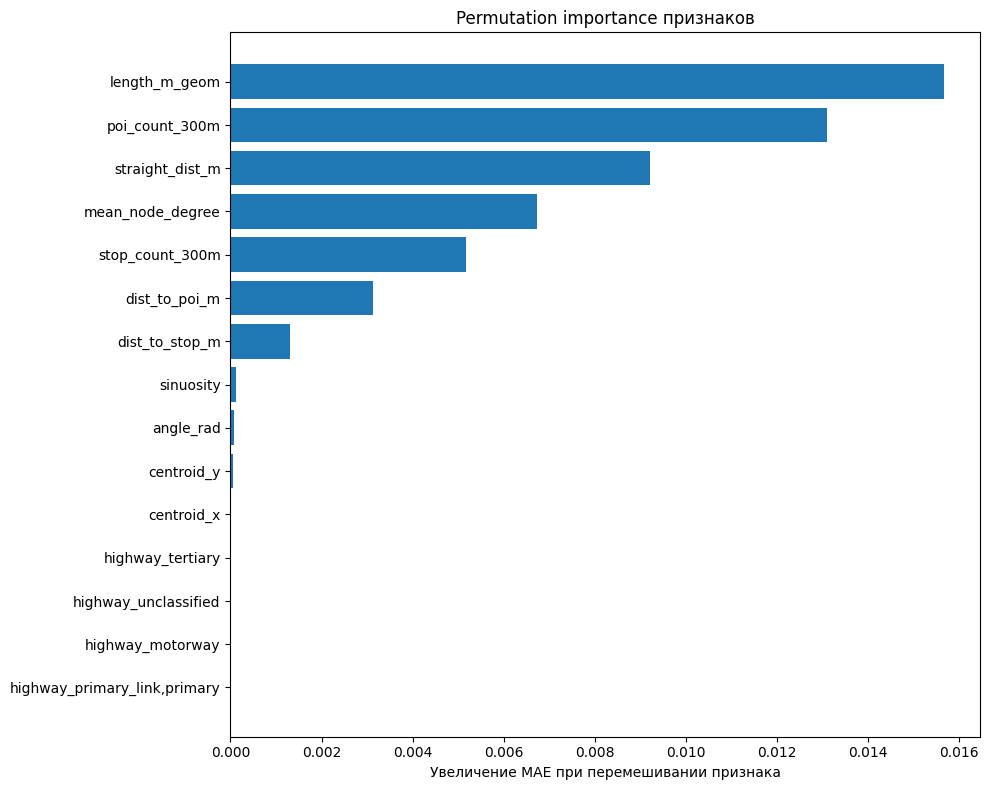

In [ ]:
top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Увеличение MAE при перемешивании признака")
plt.title("Permutation importance признаков")
plt.tight_layout()
plt.show()

## 19. Анализ ошибок по типам дорог

In [ ]:
# Добавляем предсказания в тестовую выборку
test_result = X_test.copy()
test_result["y_true"] = y_test.values
test_result["y_pred"] = best_model.predict(X_test)
test_result["abs_error"] = np.abs(test_result["y_true"] - test_result["y_pred"])

# Добавляем тип дороги для анализа
test_result["highway_type"] = roads.loc[test_result.index, "highway_str"]

# Группировка по типам дорог
error_by_road_type = (
    test_result
    .groupby("highway_type")
    .agg(
        count=("abs_error", "size"),
        mae=("abs_error", "mean"),
        mean_true=("y_true", "mean"),
        mean_pred=("y_pred", "mean")
    )
    .sort_values("mae", ascending=False)
)

error_by_road_type.head(10)

,count,mae,mean_true,mean_pred
highway_type,,,,
"primary_link,primary",1,0.086282,0.352338,0.266056
"unclassified,residential",7,0.059575,0.363541,0.369003
primary_link,57,0.047728,0.246220,0.243967
secondary_link,46,0.042515,0.262838,0.255809
tertiary_link,40,0.042099,0.223710,0.239092
"unclassified,living_street",2,0.041682,0.466966,0.425284
residential,1298,0.040376,0.304596,0.304665
motorway,18,0.040330,0.279815,0.281196
primary,462,0.040264,0.305712,0.311040


## 20. Итоговые выводы

### 1. Выполненные шаги
- Загружена дорожная сеть центра Санкт-Петербурга из OSM
- Вычислены геометрические признаки (длина, извилистость, направление)
- Добавлены пространственные признаки (близость к POI и остановкам)
- Добавлены графовые признаки (степень узлов)
- Сформирована прокси-целевая переменная на основе длины, POI, остановок и связности
- Обучена GBDT-модель с подбором гиперпараметров через GridSearch

### 2. Качество модели

| Метрика | Значение |
|---------|----------|
| Лучшие гиперпараметры | `{'learning_rate': 0.03, 'max_iter': 200, 'max_leaf_nodes': 31}` |
| Test MAE (tuned) | **0.0399** |
| Test R² (tuned) | **0.7100** |

*CV MAE при подборе гиперпараметров составил 0.0413.*

### 3. Наиболее важные признаки (permutation importance)

| Ранг | Признак | Важность | Комментарий |
|------|---------|----------|--------------|
| 1 | `length_m_geom` | 0.01568 | Длина сегмента - ключевой фактор нагрузки |
| 2 | `poi_count_300m` | 0.01310 | Концентрация POI повышает спрос на поездки |
| 3 | `straight_dist_m` | 0.00922 | Коррелирует с длиной, уточняет геометрию |
| 4 | `mean_node_degree` | 0.00673 | Связность узла отражает важность в сети |
| 5 | `stop_count_300m` | 0.00517 | Остановки добавляют мультимодальную активность |

### 4. Анализ ошибок
- **Максимальная ошибка** - у `primary_link,primary` (MAE = 0.0863), но это **единичный случай** (всего 1 сегмент)
- **Вторая по величине ошибка** - у `unclassified,residential` (MAE = 0.0596), выборка тоже мала (7 сегментов)
- **Среди массовых типов** (`residential`, `tertiary`, `primary`) ошибка стабильна и составляет **MAE ≈ 0.040**
- Съезды/развязки (`*_link`) показывают ошибку **0.042–0.048**

### 5. Визуализация
Карта прогноза показывает логичную картину: центральные магистрали и улицы с высокой плотностью POI получают более высокие оценки нагрузки.

**Вывод:** GBDT успешно справляется с задачей оценки транспортной нагрузки на основе геоданных. Полученные результаты можно использовать как baseline для более сложных моделей или как прокси-оценку там, где нет прямых измерений трафика.